<h1 style="text-align:center;">YF cross-reactivity (MHC restriction)</h1>

In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB import MMCIFParser, PDBIO, PDBParser, Superimposer

# Prepare AF3 input

In [4]:
topdir = "../260202_YF-modes/data_julien/LAU5013/YF_LAU5013_sc_WT"

threshold = 0.5

csv_file = glob.glob(f'{topdir}/*.csv')[0]
df = pd.read_csv(csv_file)
df = df[(df["TEMPOproblem"].isna()) & (df['AF3_iptm_pair_mean'] > threshold)]
df = df[['id', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB', 'AF3_iptm_pair_mean']]

df['peptide'] = 'LLWNGPMAV'
df['species'] = 'HomoSapiens'

HLAs = ['HLA_A0206', 'HLA_B1302']

for HLA in HLAs:
    tmp = df.copy()
    tmp['MHC'] = HLA
    tmp.to_csv(f'LAU5013_AF3_{HLA}_input.csv', index=False)

# Compare ipTM between complexes of different MHCs

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_9894/4172784990.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_A0201['MHC'] = 'HLA_A0201_conf'


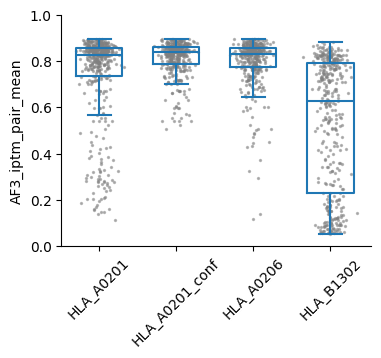

In [44]:
lst=[]

# HLA_A0201
topdir = '../260202_YF-modes/data_julien/LAU5013/YF_LAU5013_sc_WT'

csv_file = glob.glob(f'{topdir}/*.csv')[0]
df_A0201 = pd.read_csv(csv_file)

df_A0201 = df_A0201[df_A0201["TEMPOproblem"].isna()]

df_A0201 = df_A0201.drop_duplicates(subset=['TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB'])
df_A0201 = df_A0201[['id', 'AF3_iptm_pair_mean']]
df_A0201['MHC'] = 'HLA_A0201'
lst.append(df_A0201)

threshold = 0.5
df_A0201 = df_A0201[df_A0201['AF3_iptm_pair_mean'] > threshold]
df_A0201['MHC'] = 'HLA_A0201_conf'
lst.append(df_A0201)

df_A0206 = pd.read_csv('LAU5013_AF3_HLA_A0206/LAU5013_AF3_HLA_A0206_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_A0206['MHC'] = 'HLA_A0206'
lst.append(df_A0206)

df_B1302 = pd.read_csv('LAU5013_AF3_HLA_B1302/LAU5013_AF3_HLA_B1302_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_B1302['MHC'] = 'HLA_B1302'
lst.append(df_B1302)

fig, ax = plt.subplots(1, 1, figsize=(4,3))

sns.boxplot(df, x='MHC', y='AF3_iptm_pair_mean', ax=ax, showfliers=False, gap=0.25, fill=False)
x = df['MHC'].astype('category')
x_codes = x.cat.codes
jitter = np.random.normal(0, 0.1, size=len(df))
ax.scatter(x_codes + jitter, df['AF3_iptm_pair_mean'], color='grey', s=2, alpha=0.5)

ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel('')
ax.set_ylim(0,1)
sns.despine()

In [12]:
df_B1302 = pd.read_csv('LAU5013_AF3_HLA_B1302/LAU5013_AF3_HLA_B1302_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df_B1302

,id,AF3_iptm_pair_mean
0,tcr0001,0.5250
1,tcr0005,0.1125
2,tcr0008,0.0725
3,tcr0010,0.7050
4,tcr0014,0.7600
...,...,...
382,tcr4349,0.0875
383,tcr4371,0.7325
384,tcr4405,0.3625
385,tcr4448,0.8500


In [16]:
df = pd.read_csv('media-10.csv', sep=';').dropna()
df['MHC'] = np.where(df['variant to test'] == 'YF', 'HLA_A0201', 'HLA_B1302')
df['peptide'] = 'LLWNGPMAV'
df['species'] = 'HomoSapiens'
df.to_csv('YF_cross_A0201_B1302.csv', index=False)

In [19]:
df = pd.read_csv('YF_cross_A0201_B1302/YF_cross_A0201_B1302_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv('YF_cross_A0201_B1302/YF_cross_A0201_B1302_input.txt', sep='\t')
df = pd.merge(df, anno, on='id')
df

,id,AF3_iptm_pair_mean,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,TCR_number,variant to test,Tetramer (%),MHC,peptide,species,MHC_allele_a,MHC_allele_b
0,tcr0001,0.5950,TRAV4,TRAJ41,CLVDDSNSGYALNF,TRBV4-3,TRBJ1-1,CASSPSSLRTAGGAFF,TCR2,YF,"0,084",HLA_A0201,LLWNGPMAV,HomoSapiens,HLA_A0201,B2M
1,tcr0002,0.7175,TRAV4,TRAJ41,CLVDDSNSGYALNF,TRBV4-3,TRBJ1-1,CASSPSSLRTAGGAFF,TCR2,B1302,"93,8",HLA_B1302,LLWNGPMAV,HomoSapiens,HLA_B1302,B2M
2,tcr0003,0.2350,TRAV8-4,TRAJ43,CAVSLLYNNNDMRF,TRBV5-4,TRBJ1-6,CAISDSTALNSPLHF,TCR3,YF,"0,075",HLA_A0201,LLWNGPMAV,HomoSapiens,HLA_A0201,B2M
3,tcr0004,0.7375,TRAV8-4,TRAJ43,CAVSLLYNNNDMRF,TRBV5-4,TRBJ1-6,CAISDSTALNSPLHF,TCR3,B1302,"92,2",HLA_B1302,LLWNGPMAV,HomoSapiens,HLA_B1302,B2M
4,tcr0005,0.7550,TRAV27,TRAJ8,CAGVGVTGFQKLVF,TRBV9,TRBJ1-1,CASSAPDRLNTEAFF,TCR9,YF,"0,066",HLA_A0201,LLWNGPMAV,HomoSapiens,HLA_A0201,B2M
5,tcr0006,0.5350,TRAV27,TRAJ8,CAGVGVTGFQKLVF,TRBV9,TRBJ1-1,CASSAPDRLNTEAFF,TCR9,B1302,"66,7",HLA_B1302,LLWNGPMAV,HomoSapiens,HLA_B1302,B2M
